# Advanced Statistical Analysis & Hypothesis Testing

## Objective
This notebook demonstrates rigorous inferential statistical analysis on a synthetic business dataset.

**Important:** The dataset is synthetic/demo data created for demonstrating the statistical workflow. It is not presented as real-world evidence.

Analyses included:
- Shapiro-Wilk normality test
- Kolmogorov-Smirnov normality test
- Independent two-sample t-test
- Mann-Whitney U test
- One-Way ANOVA
- Tukey HSD post-hoc test
- Two-Way ANOVA
- 95% confidence intervals
- Distribution plots


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)
pd.set_option('display.max_columns', None)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Create Synthetic Business Dataset

The dataset contains sales performance for three regions and two marketing channels.

In [2]:
n = 180

regions = np.repeat(['North', 'South', 'West'], n // 3)
channels = np.tile(np.repeat(['Online', 'Offline'], n // 6), 3)

region_effect = {'North': 0, 'South': 12, 'West': 22}
channel_effect = {'Online': 10, 'Offline': 0}

sales = np.array([
    100 + region_effect[r] + channel_effect[c] + np.random.normal(0, 12)
    for r, c in zip(regions, channels)
])

df = pd.DataFrame({
    'Region': regions,
    'Channel': channels,
    'Sales': sales
})

df.head()

,Region,Channel,Sales
0,North,Online,115.960570
1,North,Online,108.340828
2,North,Online,117.772262
3,North,Online,128.276358
4,North,Online,107.190160


In [3]:
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('\nMissing values:')
print(df.isna().sum())
print('\nDescriptive statistics:')
display(df.describe())

Rows: 180
Columns: 3

Missing values:
Region     0
Channel    0
Sales      0
dtype: int64

Descriptive statistics:


,Sales
count,180.000000
mean,116.067638
std,15.819413
min,76.483959
25%,107.130684
50%,115.155225
75%,126.298200
max,158.285468


## 2. Distribution Plot

### Hypothesis for normality
**H0:** The sample is consistent with a normal distribution.

**H1:** The sample is not consistent with a normal distribution.

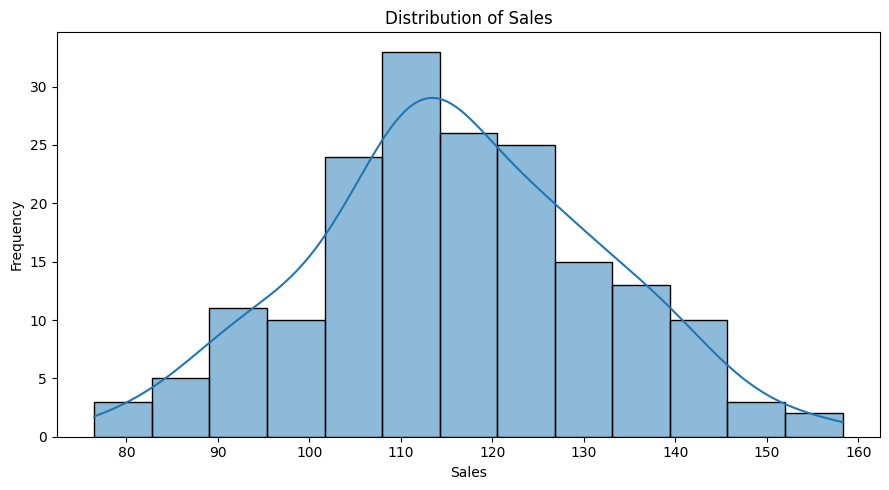

In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Shapiro-Wilk Normality Test

The Shapiro-Wilk test evaluates whether the observed sample is consistent with normality.

**Decision rule:** p < 0.05 → reject H0.

In [5]:
shapiro_stat, shapiro_p = stats.shapiro(df['Sales'])
print(f'Shapiro-Wilk statistic: {shapiro_stat:.4f}')
print(f'p-value: {shapiro_p:.4f}')
print('Decision:', 'Reject H0' if shapiro_p < 0.05 else 'Fail to reject H0')

Shapiro-Wilk statistic: 0.9957
p-value: 0.8855
Decision: Fail to reject H0


## 4. Kolmogorov-Smirnov Normality Test

The sample is standardized before comparison with the standard normal distribution.

In [6]:
standardized = (df['Sales'] - df['Sales'].mean()) / df['Sales'].std()
ks_stat, ks_p = stats.kstest(standardized, 'norm')
print(f'Kolmogorov-Smirnov statistic: {ks_stat:.4f}')
print(f'p-value: {ks_p:.4f}')
print('Decision:', 'Reject H0' if ks_p < 0.05 else 'Fail to reject H0')

Kolmogorov-Smirnov statistic: 0.0454
p-value: 0.8353
Decision: Fail to reject H0


## 5. Two-Sample t-Test

**Research question:** Do Online and Offline channels have different mean sales?

**H0:** Mean Online sales = Mean Offline sales.

**H1:** Mean Online sales ≠ Mean Offline sales.

Welch's version is used because it does not require equal population variances.

In [7]:
online = df.loc[df['Channel'] == 'Online', 'Sales']
offline = df.loc[df['Channel'] == 'Offline', 'Sales']

t_stat, t_p = stats.ttest_ind(online, offline, equal_var=False)

mean_diff = online.mean() - offline.mean()
se = np.sqrt(online.var(ddof=1)/len(online) + offline.var(ddof=1)/len(offline))
df_welch = (online.var(ddof=1)/len(online) + offline.var(ddof=1)/len(offline))**2 / (
    (online.var(ddof=1)/len(online))**2/(len(online)-1) +
    (offline.var(ddof=1)/len(offline))**2/(len(offline)-1)
)
ci = stats.t.interval(0.95, df_welch, loc=mean_diff, scale=se)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {t_p:.6f}')
print(f'Mean difference: {mean_diff:.4f}')
print(f'95% CI for mean difference: ({ci[0]:.4f}, {ci[1]:.4f})')
print('Decision:', 'Reject H0' if t_p < 0.05 else 'Fail to reject H0')

t-statistic: 3.6707
p-value: 0.000320
Mean difference: 8.3696
95% CI for mean difference: (3.8701, 12.8692)
Decision: Reject H0


## 6. Mann-Whitney U Test

This non-parametric test provides an alternative comparison of the two independent groups.

**H0:** The two groups have the same distribution.

**H1:** The distributions differ.

In [8]:
u_stat, u_p = stats.mannwhitneyu(online, offline, alternative='two-sided')
print(f'Mann-Whitney U statistic: {u_stat:.4f}')
print(f'p-value: {u_p:.6f}')
print('Decision:', 'Reject H0' if u_p < 0.05 else 'Fail to reject H0')

Mann-Whitney U statistic: 5333.0000
p-value: 0.000243
Decision: Reject H0


## 7. One-Way ANOVA

**Research question:** Does mean sales differ across regions?

**H0:** All regional mean sales are equal.

**H1:** At least one regional mean differs.

In [9]:
north = df.loc[df['Region'] == 'North', 'Sales']
south = df.loc[df['Region'] == 'South', 'Sales']
west = df.loc[df['Region'] == 'West', 'Sales']

f_stat, anova_p = stats.f_oneway(north, south, west)

print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {anova_p:.6f}')
print('Decision:', 'Reject H0' if anova_p < 0.05 else 'Fail to reject H0')

F-statistic: 63.7651
p-value: 0.000000
Decision: Reject H0


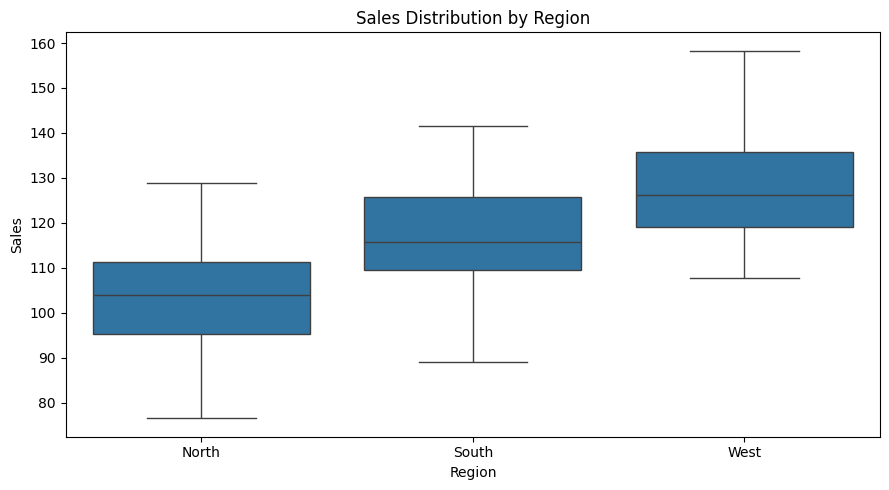

In [10]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Region', y='Sales')
plt.title('Sales Distribution by Region')
plt.tight_layout()
plt.show()

## 8. Tukey HSD Post-Hoc Analysis

If the One-Way ANOVA rejects the null hypothesis, Tukey HSD identifies which pairs of regions differ.

In [11]:
tukey = pairwise_tukeyhsd(endog=df['Sales'], groups=df['Region'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
 North  South  13.8117   0.0  8.5779 19.0454   True
 North   West  24.9588   0.0 19.7251 30.1926   True
 South   West  11.1472   0.0  5.9134 16.3809   True
---------------------------------------------------


## 9. Two-Way ANOVA

The two-way ANOVA evaluates the effects of **Region**, **Channel**, and their interaction on Sales.

**H0 for Region:** Region has no effect on mean sales.

**H0 for Channel:** Channel has no effect on mean sales.

**H0 for Interaction:** There is no Region × Channel interaction.

In [12]:
model = ols('Sales ~ C(Region) + C(Channel) + C(Region):C(Channel)', data=df).fit()
two_way = sm.stats.anova_lm(model, typ=2)
two_way

,sum_sq,df,F,PR(>F)
C(Region),18759.286398,2.0,71.929463,1.711554e-23
C(Channel),3152.280991,1.0,24.173828,2.024885e-06
C(Region):C(Channel),194.168396,2.0,0.744507,4.764750e-01
Residual,22689.699610,174.0,NaN,NaN


## 10. Final Statistical Summary

A result is treated as statistically significant when **p < 0.05**. Statistical significance does not by itself establish causation or practical importance.


In [13]:
summary = pd.DataFrame({
    'Test': [
        'Shapiro-Wilk',
        'Kolmogorov-Smirnov',
        'Welch Two-Sample t-Test',
        'Mann-Whitney U',
        'One-Way ANOVA'
    ],
    'p_value': [shapiro_p, ks_p, t_p, u_p, anova_p]
})

summary['Significant_p<0.05'] = summary['p_value'] < 0.05
summary

,Test,p_value,Significant_p<0.05
0,Shapiro-Wilk,8.855128e-01,False
1,Kolmogorov-Smirnov,8.352856e-01,False
2,Welch Two-Sample t-Test,3.196421e-04,True
3,Mann-Whitney U,2.433524e-04,True
4,One-Way ANOVA,1.394294e-21,True


## Findings

- The notebook performs both parametric and non-parametric hypothesis tests.
- Normality is assessed using Shapiro-Wilk and Kolmogorov-Smirnov tests.
- Online and Offline sales are compared using Welch's t-test and Mann-Whitney U test.
- Regional differences are evaluated using One-Way ANOVA and Tukey HSD.
- Region, Channel, and their interaction are evaluated using Two-Way ANOVA.
- Confidence intervals are reported for the primary two-group mean difference.

Because the dataset is synthetic, these results demonstrate statistical methodology rather than evidence about a real population.